[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amark-23/fno-pde/blob/main/notebooks/navier_stokes_rollout_colab.ipynb)

# FNO Part 2b: rollout-stabilized training

Compares three training schemes for the 2D Navier-Stokes FNO on their
autoregressive rollout error: the single-step **baseline**, **pushforward**
(unroll several steps, gradient on the last), and **noise injection**. Each is a
config in `configs/`; the training logic is in `src/train_ns.py`.

The goal is to flatten the rollout error-growth curve from Concept 17. Run top to
bottom on a T4 GPU.

> Note: this clones the repo from GitHub, so make sure `src/train_ns.py` and the
> `configs/ns_*.yaml` files are pushed before running.

## 1. Clone and install

In [1]:
!git clone https://github.com/amark-23/fno-pde.git
%cd fno-pde
!pip -q install pyyaml
import sys; sys.path.insert(0, '/content/fno-pde')
import torch; print('cuda:', torch.cuda.is_available(), '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')

Cloning into 'fno-pde'...
remote: Enumerating objects: 401, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 401 (delta 9), reused 15 (delta 6), pack-reused 379 (from 1)
Receiving objects: 100% (401/401), 6.79 MiB | 14.34 MiB/s, done.
Resolving deltas: 100% (195/195), done.
/content/fno-pde
cuda: True | Tesla T4


## 2. Dataset from Drive
Uses the same `navier_stokes.npz` generated for the training notebook.

In [2]:
import os, shutil
from google.colab import drive; drive.mount('/content/drive')
DRIVE_DIR = '/content/drive/MyDrive/pde_fno'; os.makedirs(DRIVE_DIR, exist_ok=True)
DATA = f'{DRIVE_DIR}/navier_stokes.npz'
old = '/content/drive/MyDrive/navier_stokes.npz'
if not os.path.exists(DATA) and os.path.exists(old):
    shutil.copy(old, DATA); print('migrated dataset into pde_fno')
assert os.path.exists(DATA), 'navier_stokes.npz not found in pde_fno; run the data-gen notebook first'
print('dataset:', DATA)


Mounted at /content/drive
dataset: /content/drive/MyDrive/pde_fno/navier_stokes.npz


## 3. Train the three variants
Each loads its config, points it at the Drive dataset, and trains. Reduce
`epochs` in the configs if a full run is too slow.

In [3]:
import yaml, os
from src.train_ns import train_rollout, load_checkpoint, save_checkpoint, load_ns_traj, eval_rollout_error

device = 'cuda' if torch.cuda.is_available() else 'cpu'
configs = {
    'baseline':    'configs/ns_baseline.yaml',
    'pushforward': 'configs/ns_pushforward.yaml',
    'noise':       'configs/ns_noise.yaml',
    'pushforward_all': 'configs/ns_pushforward_all.yaml',
}
EVAL_STEPS = 19
# test trajectories, to evaluate a loaded model without retraining
_, test_traj, _, _ = load_ns_traj(DATA, 800, 200)

results, models = {}, {}
for name, path in configs.items():
    cfg = yaml.safe_load(open(path)); cfg['data'] = DATA
    ckpt = f'{DRIVE_DIR}/ckpt_{name}.pt'
    if os.path.exists(ckpt):
        print(f'=== {name}: loading checkpoint (skip training) ===')
        model, xn, yn = load_checkpoint(ckpt, device)
        curve = eval_rollout_error(model, test_traj, xn, yn, EVAL_STEPS, device)
        res = {'single_step': curve[0], 'rollout_curve': curve}
    else:
        print(f'=== {name}: training ===')
        model, res = train_rollout(cfg, device)
        save_checkpoint(model, cfg, res['x_norm'], res['y_norm'], ckpt)
        print('saved', ckpt)
    results[name], models[name] = res, model


=== baseline: loading checkpoint (skip training) ===
=== pushforward: loading checkpoint (skip training) ===
=== noise: loading checkpoint (skip training) ===
=== pushforward_all: training ===
  epoch 5/50 [warmup k=1]  train loss 0.0669
  epoch 10/50 [warmup k=1]  train loss 0.0604
  epoch 15/50 [warmup k=1]  train loss 0.0584
  epoch 20/50 [warmup k=1]  train loss 0.0563
  epoch 25/50 [warmup k=1]  train loss 0.0555
  epoch 30/50 [warmup k=1]  train loss 0.0522
  epoch 35/50 [k=4]  train loss 0.0643
  epoch 40/50 [k=4]  train loss 0.0627
  epoch 45/50 [k=4]  train loss 0.0624
  epoch 50/50 [k=4]  train loss 0.0620
  single-step test rel-L2 0.1108 | rollout end 0.1644 | 1275s
saved /content/drive/MyDrive/pde_fno/ckpt_pushforward_all.pt


## 4. Compare rollout error growth
The headline figure: relative L2 versus rollout step for each scheme.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

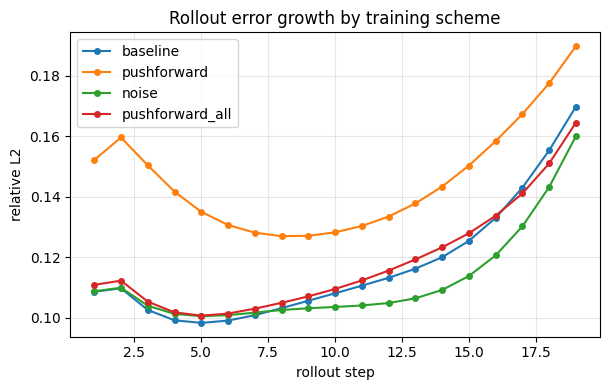

baseline     step1 0.109  end 0.170
pushforward  step1 0.152  end 0.190
noise        step1 0.109  end 0.160
pushforward_all step1 0.111  end 0.164


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6.2, 4.0))
for name, res in results.items():
    c = res['rollout_curve']
    plt.plot(range(1, len(c) + 1), c, '-o', ms=4, label=name)
plt.xlabel('rollout step'); plt.ylabel('relative L2')
plt.title('Rollout error growth by training scheme')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('/content/rollout_stability.png', dpi=130)
from google.colab import files; files.download('/content/rollout_stability.png')
plt.show()

for name, res in results.items():
    c = res['rollout_curve']
    print(f"{name:12s} step1 {c[0]:.3f}  end {c[-1]:.3f}")

## 5. Checkpoints
Checkpoints are saved to `pde_fno` automatically during training above (and reused
on the next run). This just lists what is on Drive.

In [5]:
import os
print('checkpoints in', DRIVE_DIR)
for f in sorted(os.listdir(DRIVE_DIR)):
    if f.endswith('.pt'):
        print(' ', f)


checkpoints in /content/drive/MyDrive/pde_fno
  ckpt_baseline.pt
  ckpt_noise.pt
  ckpt_pushforward.pt
  ckpt_pushforward_all.pt
  ns_checkpoint.pt
